## 🤖 4. K-Nearest Neighbors (KNN)

##### Introducción

En esta notebook se implementa el algoritmo K-Nearest Neighbors (KNN) para predecir el precio de venta de viviendas utilizando el dataset Ames Housing.

A diferencia de la regresión lineal, KNN es un algoritmo no paramétrico que realiza sus predicciones basándose en la similitud entre observaciones. Para estimar el precio de una vivienda, el modelo identifica las viviendas más parecidas según sus características y calcula la predicción a partir de ellas.

❓ Preguntas a responder en esta notebook
- ¿Puede KNN predecir el precio de venta de una vivienda?
- ¿Cuál es el número óptimo de vecinos (k)?
- ¿Cómo influye el escalado de las variables?
- ¿Qué desempeño obtiene respecto a la regresión lineal?

In [1]:
# Librerias 
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, accuracy_score,confusion_matrix,classification_report
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
import seaborn as sns
import plotly.express as px
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor

print ("librerias ok")

librerias ok


d:\Josefina\Proyectos\Datascience\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [48]:
# Leemos el dataset generado anteriormente
df = pd.read_csv("../data/AmesHousing_modificado.csv")
print(df.shape) 
df.head(5)

(2930, 23)


,Unnamed: 0,SalePrice,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,Year Built,Year Remod/Add,Full Bath,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Neighborhood,Kitchen Qual,Exter Qual,Bsmt Qual,Garage Finish,Foundation,House Style,Sale Condition
0,0,215000,6,1656,1080.0,528.0,1960,1960,1,112.0,...,210,62,NAmes,TA,TA,TA,Fin,CBlock,1Story,Normal
1,1,105000,5,896,882.0,730.0,1961,1961,1,0.0,...,140,0,NAmes,TA,TA,TA,Unf,CBlock,1Story,Normal
2,2,172000,6,1329,1329.0,312.0,1958,1958,1,108.0,...,393,36,NAmes,Gd,TA,TA,Unf,CBlock,1Story,Normal
3,3,244000,7,2110,2110.0,522.0,1968,1968,2,0.0,...,0,0,NAmes,Ex,Gd,TA,Fin,CBlock,1Story,Normal
4,4,189900,5,1629,928.0,482.0,1997,1998,2,0.0,...,212,34,Gilbert,TA,TA,Gd,Fin,PConc,2Story,Normal


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      2930 non-null   int64  
 1   SalePrice       2930 non-null   int64  
 2   Overall Qual    2930 non-null   int64  
 3   Gr Liv Area     2930 non-null   int64  
 4   Total Bsmt SF   2929 non-null   float64
 5   Garage Area     2929 non-null   float64
 6   Year Built      2930 non-null   int64  
 7   Year Remod/Add  2930 non-null   int64  
 8   Full Bath       2930 non-null   int64  
 9   Mas Vnr Area    2907 non-null   float64
 10  Fireplaces      2930 non-null   int64  
 11  Lot Area        2930 non-null   int64  
 12  Lot Frontage    2440 non-null   float64
 13  Wood Deck SF    2930 non-null   int64  
 14  Open Porch SF   2930 non-null   int64  
 15  Neighborhood    2930 non-null   str    
 16  Kitchen Qual    2930 non-null   str    
 17  Exter Qual      2930 non-null   str    
 18 

In [45]:
#Hacemos una copia
df_model = df.copy()
#Hay algunas variables en el csv que no deberian estar, las borramos
df_model = df_model.drop(columns=["Unnamed: 0.1", "Unnamed: 0"])

In [46]:
# Variable objetivo
y = df_model["SalePrice"]

# Variables predictoras
X = df_model.drop(columns="SalePrice")


print(f"Cantidad de observaciones: {len(df_model)}")
print(f"Número de variables predictoras: {X.shape[1]}")


X.head()

Cantidad de observaciones: 2705
Número de variables predictoras: 62


,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,Year Built,Year Remod/Add,Full Bath,Mas Vnr Area,Fireplaces,Lot Area,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,6,1656,1080.0,528.0,1960,1960,1,112.0,2,31770,...,0,0,0,0,0,0,0,0,0,0
1,5,896,882.0,730.0,1961,1961,1,0.0,0,11622,...,0,0,0,0,0,0,0,0,0,0
2,6,1329,1329.0,312.0,1958,1958,1,108.0,0,14267,...,0,0,0,0,0,0,0,0,0,0
3,7,2110,2110.0,522.0,1968,1968,2,0.0,2,11160,...,0,0,0,0,0,0,0,0,0,0
4,5,1629,928.0,482.0,1997,1998,2,0.0,1,13830,...,0,0,0,0,0,0,0,0,0,0


In [47]:
#01. Se dividen los datos en entrenamiento y testeo como venimos haciendo
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.20, random_state = 42)

In [7]:
# 02. Estandarizar para poder medir distancias
scaler = StandardScaler()


In [8]:
# 03. Aca se estandarizan todas las variables para dejarlas listas
# La diferencia está en que uno aprende los parámetros del escalado y el otro solo los aplica.
X_train_scaled = scaler.fit_transform (X_train)

X_test_scaled = scaler.transform (X_test)

In [11]:
# 04 Comenzamos a implementar el modelo KNN
# Probar distintos cantidad de vecinos para ver como mejora/empeora el modelo
cantidad_vecinos = 5

#En este caso es un modelo de clasificacion
modelo_knn = KNeighborsRegressor(n_neighbors=cantidad_vecinos)

In [12]:
# 05. Aplico el modelo a mis datos: entrenamiento
modelo_knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [13]:
# 06. Predecir
y_pred = modelo_knn.predict(X_test_scaled)

In [14]:
# 07. Evaluamos el modelo con la matriz de confusion

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 23208.60
RMSE: 36126.14
R²: 0.811


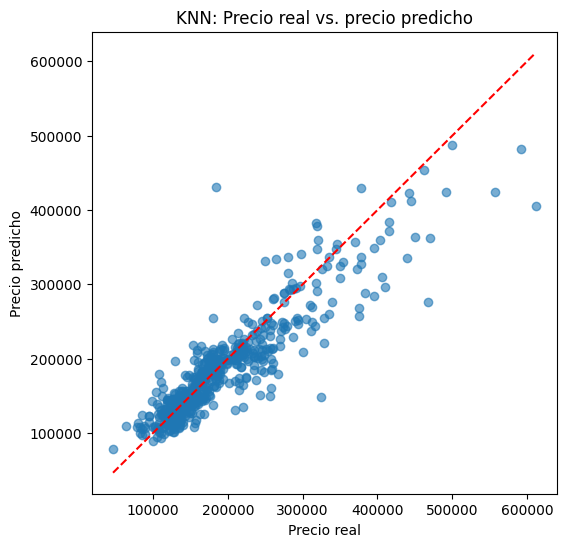

In [15]:
# 08. hacemos un plot para entender mejor las metricas

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("KNN: Precio real vs. precio predicho")

plt.show() 

In [36]:
# Ahora probamos diferentes valores de k para ver cual es el mejor
valores_k = range(1, 21)
r2_scores = []
rmse_scores = []
mae_scores = []
for k in valores_k:
    modelo = KNeighborsRegressor(n_neighbors=k)
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    r2_scores.append(round(r2_score(y_test, y_pred),2))
    mae_scores.append(round(mean_absolute_error(y_test, y_pred),1))
    rmse_scores.append(round(np.sqrt(mean_squared_error(y_test, y_pred)),1))
    
df_resultados = pd.DataFrame({
    "Cantidad de vecinos": valores_k,
    "R2": r2_scores, 
    "RMSE": rmse_scores,
    "mae" : mae_scores
})
print(df_resultados)

    Cantidad de vecinos    R2     RMSE      mae
0                     1  0.58  53501.6  36727.3
1                     2  0.65  49200.7  32698.3
2                     3  0.66  48698.7  32319.8
3                     4  0.65  49162.3  32628.7
4                     5  0.66  48398.1  32165.5
5                     6  0.66  48103.5  31536.1
6                     7  0.66  48394.4  31624.5
7                     8  0.67  47821.9  31613.1
8                     9  0.66  48076.7  31898.9
9                    10  0.66  48224.5  32077.4
10                   11  0.67  47837.8  31676.2
11                   12  0.66  48290.1  32143.7
12                   13  0.66  48455.4  32298.4
13                   14  0.65  48949.8  32575.0
14                   15  0.65  49293.9  32982.7
15                   16  0.64  49673.0  33325.6
16                   17  0.64  50022.9  33557.3
17                   18  0.63  50303.9  33704.0
18                   19  0.63  50288.0  33587.8
19                   20  0.63  50433.1  

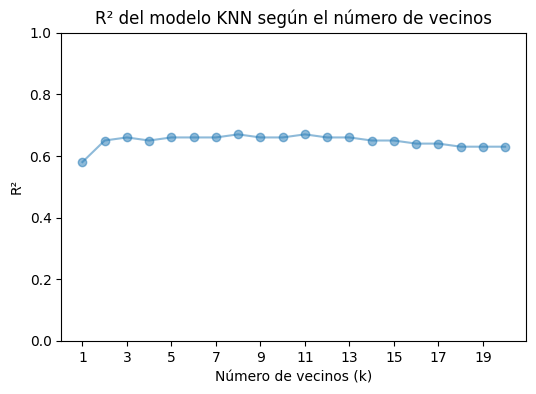

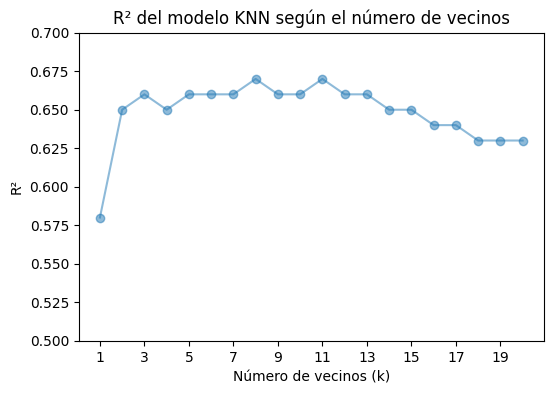

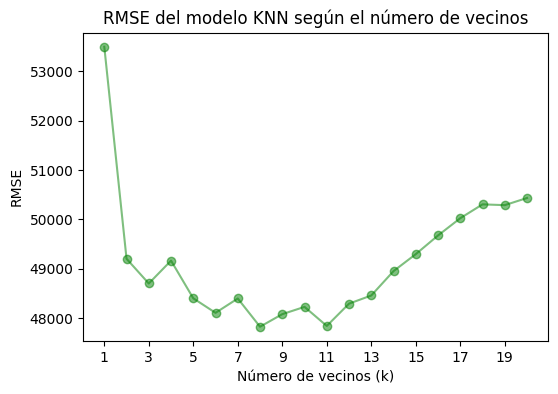

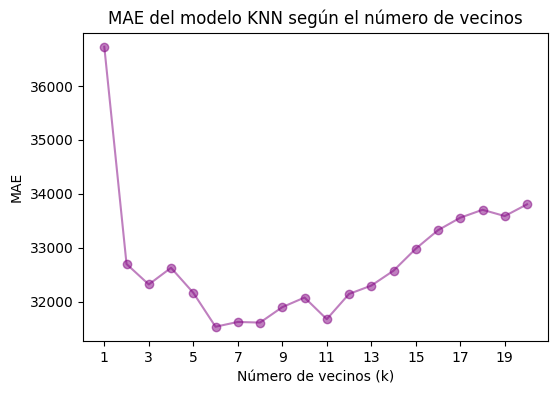

In [38]:
#Plot con los resultados de las pruebas
# R2
plt.figure(figsize=(6,4))
plt.plot(valores_k, r2_scores, marker="o", alpha=0.5)
# Mostrar todos los valores de k
plt.xticks(range(min(valores_k), max(valores_k) + 1, 2))
# Limitar el eje Y
plt.ylim(0, 1)
plt.xlabel("Número de vecinos (k)")
plt.ylabel("R²")
plt.title("R² del modelo KNN según el número de vecinos")

# plt.grid(True)
plt.show()

####
# Misma metrica de R2 pero con otros rangos en el eje Y
plt.figure(figsize=(6,4))
plt.plot(valores_k, r2_scores, marker="o", alpha=0.5)
# Mostrar todos los valores de k
plt.xticks(range(min(valores_k), max(valores_k) + 1, 2))
# Limitar el eje Y
plt.ylim(0.5, 0.7)
plt.xlabel("Número de vecinos (k)")
plt.ylabel("R²")
plt.title("R² del modelo KNN según el número de vecinos")

# plt.grid(True)
plt.show()

# -------------------------------------------------------------
# RMSE
plt.figure(figsize=(6,4))
plt.plot(valores_k, rmse_scores, marker="o", c= "green", alpha=0.5)
# Mostrar todos los valores de k
plt.xticks(range(min(valores_k), max(valores_k) + 1, 2))
# Limitar el eje Y
# plt.ylim(0, 1)
plt.xlabel("Número de vecinos (k)")
plt.ylabel("RMSE")
plt.title("RMSE del modelo KNN según el número de vecinos")

# plt.grid(True)
plt.show()


# -------------------------------------------------------------
# MAE
plt.figure(figsize=(6,4))
plt.plot(valores_k, mae_scores, marker="o", c= "purple", alpha=0.5)
# Mostrar todos los valores de k
plt.xticks(range(min(valores_k), max(valores_k) + 1, 2))
# Limitar el eje Y
# plt.ylim(0, 1)
plt.xlabel("Número de vecinos (k)")
plt.ylabel("MAE")
plt.title("MAE del modelo KNN según el número de vecinos")

# plt.grid(True)
plt.show()

Resumen de resultados:
- El modelo va mejorandp al aumentar k desde valores pequeños. k = 1 es el peor resultado. Esto es esperable porque con un único vecino el modelo es muy sensible a observaciones particulares y al ruido.
- Mejora importante entre k = 1 y k≈8.
- Si vemos el R2 los mejores resultados son k = 8 (0.67) y k = 11 (0.67).
- Si vemos el RMSE los mejores resultados son k = 8 (47.821) y k = 11 (47.837).
- Ambos modelos coinciden pero hay una leve mejora en el k=8
- Despues del k = 11 comienza un deterioro.
- Sin embargo, los valores obtenidos de las métricas muestran que el modelo todavía presenta margen de mejora. 
Esto puede deberse a varios factores, como la selección de variables utilizadas, la representación de las variables categóricas o la configuración de los hiperparámetros del modelo.


In [43]:
df_model.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'SalePrice', 'Overall Qual',
       'Gr Liv Area', 'Total Bsmt SF', 'Garage Area', 'Year Built',
       'Year Remod/Add', 'Full Bath', 'Mas Vnr Area', 'Fireplaces', 'Lot Area',
       'Lot Frontage', 'Wood Deck SF', 'Open Porch SF', 'Kitchen Qual',
       'Exter Qual', 'Bsmt Qual', 'Garage Finish', 'Mas Vnr Area ',
       'House Style_1.5Unf', 'House Style_1Story', 'House Style_2.5Fin',
       'House Style_2.5Unf', 'House Style_2Story', 'House Style_SFoyer',
       'House Style_SLvl', 'Foundation_CBlock', 'Foundation_PConc',
       'Foundation_Slab', 'Foundation_Stone', 'Foundation_Wood',
       'Sale Condition_AdjLand', 'Sale Condition_Alloca',
       'Sale Condition_Family', 'Sale Condition_Normal',
       'Sale Condition_Partial', 'Neighborhood_Blueste', 'Neighborhood_BrDale',
       'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr',
       'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert',
       'Neighb